In [57]:
#RANDOM FOREST WITHOUT SKLEARN
import numpy as np
import pandas as pd

In [58]:
# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00254/biodeg.csv"

data = pd.read_csv(url, sep=';', header=None)

# Features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Convert labels
y = np.where(y == 'RB', 1, 0)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1055, 41)
Shape of y: (1055,)


In [59]:
#Splitting data
indices = np.arange(len(X))
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 844
Testing samples: 211


In [60]:
#TREE NODE CLASS/ creating a node class to build the decision tree
class Node:
    def __init__(self, feature=None, threshold=None,
                 left=None, right=None, value=None):

        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

In [61]:
#creating the decision tree class to build the decision tree and random forest
class DecisionTree:

    def __init__(self, max_depth=10, min_samples_split=2,
                 n_features=None): #sets the rules for the decision tree

        self.max_depth = max_depth #maximum depth of the tree
        self.min_samples_split = min_samples_split #minimum number of samples required to split an internal node
        self.n_features = n_features #number of features to consider when looking for the best split
        self.root = None #root node of the tree

    # Train tree
    def fit(self, X, y): #fits the decision tree to the training data

        self.n_features = (
            X.shape[1] #number of features in the dataset
            if not self.n_features #if n_features is not specified, use all features
            else min(self.n_features, X.shape[1]) 
        )

        self.root = self._grow_tree(X, y) #grows the tree recursively starting from the root node

    # Build tree recursively
    def _grow_tree(self, X, y, depth=0): 

        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # Stop conditions
        if (
            depth >= self.max_depth or #if the maximum depth is reached, stop splitting 
            n_labels == 1 or #if all samples belong to the same class, stop splitting
            n_samples < self.min_samples_split #if the number of samples is less than the minimum required to split, stop splitting
        ):

            leaf_value = self._most_common_label(y) #if any stop conditions are met, create a leaf node with the most common label in the current node
            return Node(value=leaf_value)

        # Random feature selection
        feat_idxs = np.random.choice( #randomly select a subset of features to consider for the best split
            n_features,
            self.n_features,
            replace=False
        )

        # Find best split
        best_feature, best_thresh = self._best_split( #find the best feature and threshold to split the data based on the selected features
            X, y, feat_idxs
        )

     
        if best_feature is None: 
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value) #if no valid split is found, create a leaf node with the most common label in the current node

        # Split data
        left_idxs, right_idxs = self._split(
            X[:, best_feature], #split the data based on the best feature and threshold
            best_thresh
        )

       
        if len(left_idxs) == 0 or len(right_idxs) == 0: #if the split results in an empty left or right child
            leaf_value = self._most_common_label(y) #find the most common label in the current node
            return Node(value=leaf_value) #

        # Recursive growth of the subtrees
        left = self._grow_tree(
            X[left_idxs, :],
            y[left_idxs], 
            depth + 1 #increment the depth for the recursive call
        )

        right = self._grow_tree(
            X[right_idxs, :],
            y[right_idxs],
            depth + 1
        )

        #return a new node with the best feature, threshold, and left and right subtrees
        return Node( 
            best_feature,
            best_thresh,
            left,
            right
        )

    # Best split finder
    def _best_split(self, X, y, feat_idxs): 

        best_gain = -1
        split_idx, split_thresh = None, None 

        for feat_idx in feat_idxs: #iterate over the selected features to find the best split

            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)

            for threshold in thresholds: #iterate over the unique values of the selected feature to find the best threshold for splitting

                gain = self._information_gain( #calculate the information gain for the current feature and threshold
                    y,
                    X_column,
                    threshold
                )

                if gain > best_gain: #if the calculated gain is better than the best gain found so far,
                #update the best gain, split index, and split threshold
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = threshold

        return split_idx, split_thresh 

    # Gini impurity
    def _gini(self, y): #calculate the Gini impurity for a given set of labels

        if len(y) == 0:
            return 0

        proportions = np.bincount(y) / len(y) #calculate the proportion of each class in the current node

        return 1 - np.sum(proportions ** 2)

    # Information gain
    def _information_gain(self, y, X_column, threshold): #calculate the information gain for a given feature and threshold
 
        parent_gini = self._gini(y) #calculate the Gini impurity of the parent node before the split

        left_idxs, right_idxs = self._split( 
            X_column,
            threshold
        )

        if len(left_idxs) == 0 or len(right_idxs) == 0: #if the split results in an empty left or right child, return an information gain of 0
            return 0

        n = len(y)

        n_l = len(left_idxs)
        n_r = len(right_idxs)

        left_gini = self._gini(y[left_idxs])
        right_gini = self._gini(y[right_idxs])

        child_gini = ( #
            (n_l / n) * left_gini +
            (n_r / n) * right_gini
        )

        information_gain = parent_gini - child_gini

        return information_gain

    # Split function
    def _split(self, X_column, threshold): #split the data based on the given feature column and threshold

        left_idxs = np.argwhere(
            X_column <= threshold
        ).flatten()

        right_idxs = np.argwhere(
            X_column > threshold
        ).flatten()

        return left_idxs, right_idxs

    # Majority class
    def _most_common_label(self, y): #find the most common label to determine the value of a leaf node

        if len(y) == 0:
            return 0

        counts = np.bincount(y)

        return np.argmax(counts)

    # Predict
    def predict(self, X): #predict the class labels for the given input data by traversing the decision tree

        return np.array([
            self._traverse_tree(x, self.root)
            for x in X
        ])

    # Traverse tree
    def _traverse_tree(self, x, node): #traverse the decision tree recursively to make a prediction for a single input sample   

        if node.value is not None:
            return node.value

        if x[node.feature] <= node.threshold: 
            return self._traverse_tree(x, node.left)

        return self._traverse_tree(x, node.right) 


#DecisionTree class repeatedly finds the feature and threshold that best separate biodegradable and non-biodegradable molecules, builds a hierarchy of yes/no questions, and then uses that hierarchy to classify new molecules.

In [62]:
# RANDOM FOREST IMPLEMENTATION
class RandomForest: 

    def __init__(self,
                 n_trees=10,
                 max_depth=10,
                 min_samples_split=2,
                 n_features=None): 

        self.n_trees = n_trees 
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features

        self.trees = []

    # Bootstrap sampling
    def _bootstrap_samples(self, X, y): 

        n_samples = X.shape[0]

        idxs = np.random.choice(
            n_samples,
            n_samples,
            replace=True
        )

        return X[idxs], y[idxs]

    # Train forest
    def fit(self, X, y): 

        self.trees = []

        for _ in range(self.n_trees):

            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                n_features=self.n_features
            )

            X_sample, y_sample = self._bootstrap_samples(X, y)

            tree.fit(X_sample, y_sample)

            self.trees.append(tree)

    # Predict class labels
    def predict(self, X): 

        predictions = np.array([
            tree.predict(X)
            for tree in self.trees #collect the predictions from each tree in the forest for the input data X
        ])

        tree_preds = np.swapaxes(predictions, 0, 1)

        predictions = np.array([
            np.bincount(pred).argmax() #for each sample, find the most common prediction and use that as the final prediction
            for pred in tree_preds
        ])

        return predictions
    
    # Predict probabilities
    def predict_proba(self, X): 

        predictions = np.array([
            tree.predict(X)
            for tree in self.trees
        ])

        # Average votes
        probabilities = np.mean(predictions, axis=0) #calculate the average predicted probabilities for each class across all trees in the forest

        return probabilities

In [63]:
#TRAINING THE MODEL
rf = RandomForest( 
    n_trees=20,
    max_depth=10,
    n_features=int(np.sqrt(X.shape[1])) 
)

rf.fit(X_train, y_train) #fit the random forest model to the training data

predictions = rf.predict(X_test) #use the trained random forest model to predict the class labels for the test data

accuracy = np.sum(predictions == y_test) / len(y_test) 

print("Accuracy:", accuracy)

Accuracy: 0.8767772511848341


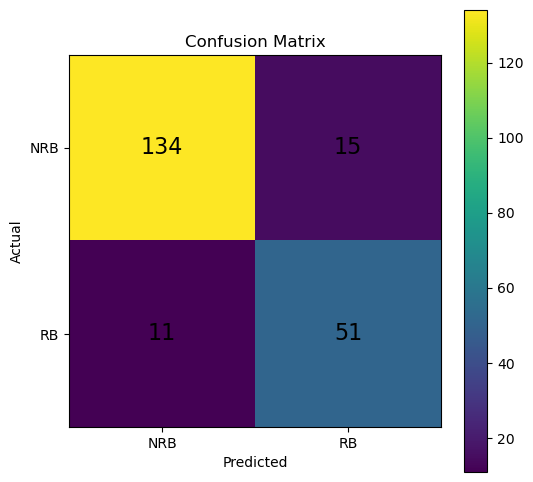

In [64]:
#CONFUSION MATRIX
import matplotlib.pyplot as plt

# Confusion matrix values
TP = np.sum((y_test == 1) & (predictions == 1))
TN = np.sum((y_test == 0) & (predictions == 0))
FP = np.sum((y_test == 0) & (predictions == 1))
FN = np.sum((y_test == 1) & (predictions == 0))

# Matrix
cm = np.array([
    [TN, FP],
    [FN, TP]
])

# Plot confusion matrix
plt.figure(figsize=(6,6))

plt.imshow(cm)

# Labels
plt.xticks([0,1], ["NRB", "RB"])
plt.yticks([0,1], ["NRB", "RB"])

# Numbers inside boxes
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j],
                 ha='center',
                 va='center',
                 fontsize=16)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.colorbar()

plt.show()

In [65]:
#CLASSIFICATION REPORT

TP = np.sum((y_test == 1) & (predictions == 1))
TN = np.sum((y_test == 0) & (predictions == 0))
FP = np.sum((y_test == 0) & (predictions == 1))
FN = np.sum((y_test == 1) & (predictions == 0))

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0
    else 0
)

# Support
support_RB = np.sum(y_test == 1)
support_NRB = np.sum(y_test == 0)

# Print report
print("\nClassification Report")
print("=" * 40)

print(f"{'Metric':<15}{'Value':>10}")
print("-" * 40)

print(f"{'Accuracy':<15}{accuracy:>10.4f}")
print(f"{'Precision':<15}{precision:>10.4f}")
print(f"{'Recall':<15}{recall:>10.4f}")
print(f"{'F1 Score':<15}{f1_score:>10.4f}")

print("-" * 40)

print("\nSupport")
print(f"RB  : {support_RB}")
print(f"NRB : {support_NRB}")


Classification Report
Metric              Value
----------------------------------------
Accuracy           0.8768
Precision          0.7727
Recall             0.8226
F1 Score           0.7969
----------------------------------------

Support
RB  : 62
NRB : 149


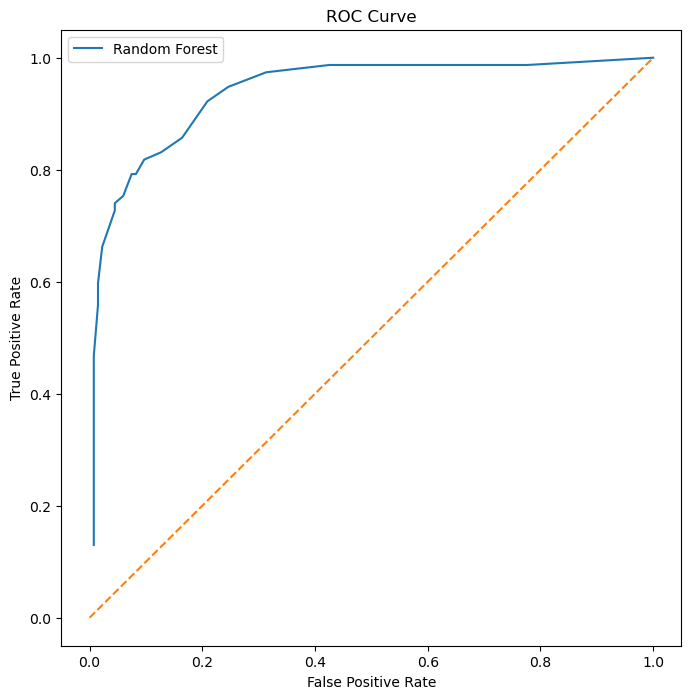

In [56]:
#ROC CURVE
import matplotlib.pyplot as plt

# Get probabilities
probabilities = rf.predict_proba(X_test)

# Threshold values
thresholds = np.linspace(0, 1, 100)

tpr_list = []
fpr_list = []

for threshold in thresholds:

    predicted = (probabilities >= threshold).astype(int)

    TP = np.sum((y_test == 1) & (predicted == 1))
    TN = np.sum((y_test == 0) & (predicted == 0))
    FP = np.sum((y_test == 0) & (predicted == 1))
    FN = np.sum((y_test == 1) & (predicted == 0))

    # True Positive Rate
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0

    # False Positive Rate
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

    tpr_list.append(TPR)
    fpr_list.append(FPR)

# Plot ROC curve
plt.figure(figsize=(8,8))

plt.plot(fpr_list, tpr_list, label="Random Forest")

# Random guessing line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
#references
#https://github.com/spaul1014/Implementation-of-Random-Forest-Algorithm-From-Scratch